# Mathematical Sequences and Attractors: A Visualization Portfolio

## Introduction

This notebook explores mathematical concepts through visualization. We delve into sequences from the Online Encyclopedia of Integer Sequences (OEIS), chaotic dynamics via the Feigenbaum constant, prime number distributions in the Ulam spiral, and the Lorenz attractor.

The six plots presented here showcase:
- Three OEIS sequences including the Wisteria sequence
- The Feigenbaum bifurcation diagram
- Prime numbers in a spiral pattern (Ulam spiral)
- A projection of the Lorenz attractor

Each visualization is generated using Python with libraries like Matplotlib, NumPy, and SymPy.

## Implementation

The following sections implement the mathematical sequences and attractors. Each code block generates the data for one visualization, using efficient algorithms and Python's scientific computing ecosystem.

### OEIS Sequences
We start with three sequences from the OEIS database, including the Wisteria sequence which subtracts the product of a number's digits from the number itself.

### Feigenbaum Constant
This section computes the bifurcation diagram for the logistic map, illustrating the route to chaos.

### Ulam Spiral
Prime numbers are plotted on a spiral grid, revealing their distribution patterns.

### Lorenz Attractor
The Lorenz system of differential equations is numerically integrated to generate the attractor data.

In [231]:
import matplotlib.pyplot as plt
import math
from sympy import isprime
import numpy as np

In [232]:
# Wisteria sequence
def wisteria(num):
    prod = 1
    for x in str(num):
        if int(x) != 0:
            prod *= int(x)
    return num - prod

x1, y1 = [], []
for i in range(1, 2000):
    x1.append(i)
    y1.append(wisteria(i))


In [233]:
# Sequence A133058
x2, y2 = [0, 1], [1, 1]
for i in range(2, 1000):
    gd = math.gcd(i, y2[-1])
    if gd == 1:
        y2.append(y2[-1]+i+1)
    else:
        y2.append(int(y2[-1] / gd))
    x2.append(i)

In [234]:
# Sequence A265326
x3 = []
y3 = []
for i in range(100000):
    if isprime(i):
        x3.append(i)
        reversed = int(bin(i)[2:][::-1], 2)
        y3.append(i-reversed)

In [235]:
# Feigenbaum
old = 0.75
x4, y4 = [],[]

for j in range(1000, 4000):
    for i in range(40):
        new = (j/1000)*old*(1-old)
        old = new
        x4.append(j/1000)
        y4.append(new)

In [236]:
# Ulam spiral
def draw_spiral(size):
    n = size
    grid = [[0 for _ in range(n)] for _ in range(n)]

    # start from the center
    x = y = n // 2
    num = 1
    grid[y][x] = num

    # directions: right, up, left, down
    dirs = [(1, 0), (0, -1), (-1, 0), (0, 1)]

    step = 1  # how many cells to move in one direction
    while num < (n - 1) * (n - 1):
        for dx, dy in dirs:
            for _ in range(step):
                if num >= (n - 1) * (n - 1):
                    break
                x += dx
                y += dy
                num += 1
                grid[y][x] = num
            # after moving horizontally and vertically, increase step size
            if (dx, dy) in [(0, -1), (0, 1)]:
                step += 1
    return grid

grid = draw_spiral(100)

to_draw_x, to_draw_y = [], []
for i in range(len(grid)):
    for j in range(len(grid[0])):
        if isprime(grid[i][j]):
            to_draw_x.append(j)
            to_draw_y.append(n - i)

In [237]:
x_arr, y_arr, z_arr = [0.0], [1.0], [1.05]

def lorenz_attractor(x, y, z):
    s, r, b = 10, 28, 2.667
    x_dot = s*(y - x)
    y_dot = r*x - y - x*z
    z_dot = x*y - b*z
    return [x_dot, y_dot, z_dot]

dt = 0.01
num_steps = 10000

for _ in range(num_steps):
    x_arr.append(x_arr[-1] + lorenz_attractor(x_arr[-1], y_arr[-1], z_arr[-1])[0] * dt)
    y_arr.append(y_arr[-1] + lorenz_attractor(x_arr[-1], y_arr[-1], z_arr[-1])[1] * dt)
    z_arr.append(z_arr[-1] + lorenz_attractor(x_arr[-1], y_arr[-1], z_arr[-1])[2] * dt)

## Results

The visualizations below combine all six mathematical concepts into a single comprehensive figure:

- **Top Row**: OEIS sequences showing patterns in integer relationships
- **Bottom Left**: Chaotic behavior emerging from simple rules (Feigenbaum)
- **Bottom Center**: Prime number distribution in spiral form (Ulam)
- **Bottom Right**: Strange attractor from fluid dynamics (Lorenz)

The plots use Matplotlib's subplot functionality for clear comparison and professional presentation.

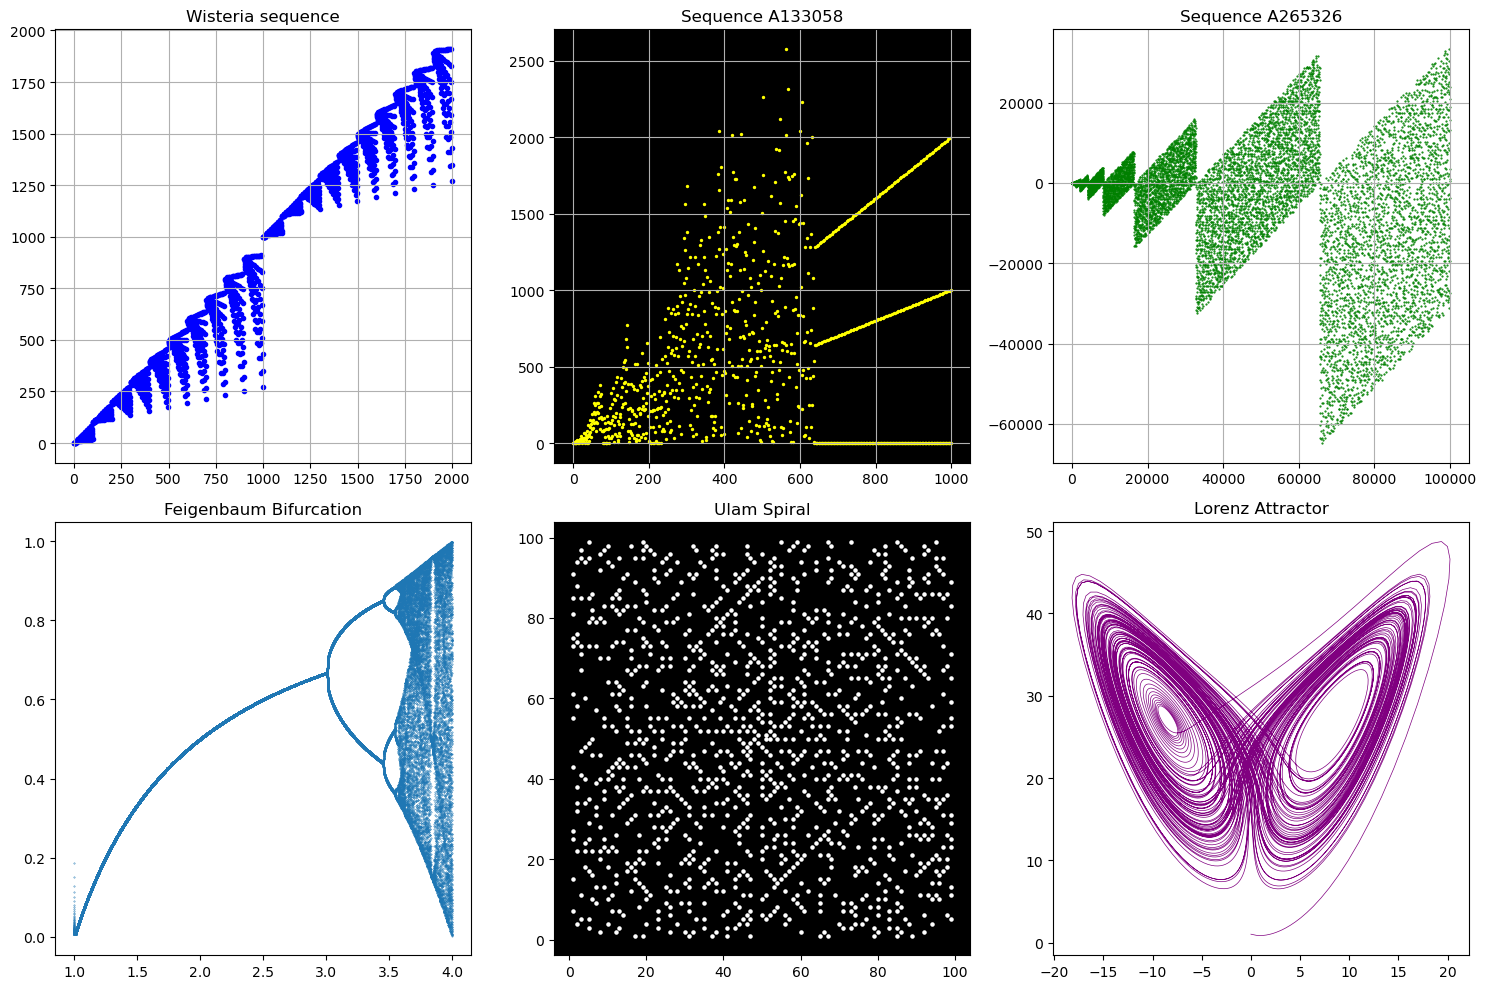

In [239]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 10))

ax1.set_title('Wisteria sequence')
ax1.grid(True)
ax1.scatter(x1, y1, s=9, color='blue')

ax2.set_title('Sequence A133058')
ax2.set_facecolor('black')
ax2.grid(True)
ax2.scatter(x2, y2, s=2, color='yellow')

ax3.set_title('Sequence A265326')
ax3.grid(True)
ax3.scatter(x3, y3, s=0.3, color='green')

ax4.set_title('Feigenbaum Bifurcation')
ax4.scatter(x4, y4, s=0.1)

ax5.set_title('Ulam Spiral')
ax5.set_facecolor('black')
ax5.scatter(to_draw_x, to_draw_y, s=5, c='white')

ax6.set_title('Lorenz Attractor')
ax6.plot(x_arr, z_arr, color='purple', linewidth=0.5)

plt.tight_layout()
plt.show()

## Reflection

This project demonstrates the intersection of mathematics, programming, and visualization.

Key takeaways:
- Programming enables exploration of complex mathematical concepts
- Visualization makes abstract ideas tangible and beautiful
- Simple rules can generate infinite complexity

Future enhancements could include interactive plots, 3D Lorenz visualization, or additional OEIS sequences.